# 04c - Latent Propagator Comparison

Train one shared latent autoencoder, then compare different latent propagators on the same encoded trajectories.

The baseline propagator uses the historical normalized `dz` objective. The JEPA-style option predicts the next latent embedding directly (`z(t+1)`) and is evaluated by autoregressive rollout through the same decoder.


In [19]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from lss.data import resolve_dataset_splits
from lss.latent.models import NodeDeltaAttentionAutoEncoder
from lss.latent import simulation as latent_sim_utils
from lss.latent import training as latent_train_utils
from lss.utils import resolve_device

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 220,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})





In [20]:
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
print('run seed:', seed)

selected_dataset = 'depablo'  # 'reid' or 'depablo'

dataset_specs = {
    'reid': {
        'label': 'Reid',
        'path': '../../data/new_reid_combined.pt',
        'train_count': 20,
        'val_count': 20,
    },
    'depablo': {
        'label': 'dePablo OOL',
        'path': '../../data/2340_dePablo_networks_OOL_undirected.pt',
        'train_count': 10,
        'val_count': 25,
    },
}

cfg = {
    'dataset_name': selected_dataset,
    'split_seed': seed,
    'shuffle_dataset_within_source': True,
    'device': 'auto',
    'pos_dim': 2,
    'batch_graphs': 8,
    'frame_skip': 1,
    'train_frame_start_order': 1,
    'latent_dim': 4,
    'latent_tokens': 8,
    'hidden_size': 90,
    'ae_train_frames_per_sim': 30,
    'dyn_train_transitions_per_sim': 30,
    'ae_target_mode': 'delta',
    'node_feature_mode': 'delta',
    'ae_max_epochs': 250,
    'ae_patience': 8,
    'ae_lr': 2e-4,
    'ae_weight_decay': 1e-5,
    'propagator_max_epochs': 250,
    'propagator_patience': 8,
    'propagator_lr': 2e-4,
    'propagator_weight_decay': 1e-5,
    'multistep_horizons': [1, 5, 10, 20],
    'multistep_max_starts_per_sim': 50,
    'early_stop_min_delta': 1e-5,
    'rollout_step_stride': 10,
    'rollout_max_requested_steps': 500,
    'cap_rollout_to_available_gt': True,
    'include_final_available_rollout_step': True,
    'rollout_steps_grid': list(range(10, 301, 10)),
    'p_ratio_methods': ['rollout_sides', 'box', 'rollout_all', 'rollout_outer'],
    'force_train_ae': True,
    'force_train_propagators': True,
    'propagator_repeats': 3,
    'output_dir': Path('../results/latent_propagator_comparison') / selected_dataset,
}

propagator_specs = [
    # {'name': 'delta_residual_mlp90', 'loss_mode': 'delta', 'model_type': 'residual_mlp', 'train_objective': 'one_step', 'hidden_size': 90},
    # {'name': 'delta_residual_mlp32', 'loss_mode': 'delta', 'model_type': 'residual_mlp', 'train_objective': 'one_step', 'hidden_size': 32},
    {'name': 'delta_residual_mlp8', 'loss_mode': 'delta', 'model_type': 'residual_mlp', 'train_objective': 'one_step', 'hidden_size': 8},
     {'name': 'delta_residual_mlp2', 'loss_mode': 'delta', 'model_type': 'residual_mlp', 'train_objective': 'one_step', 'hidden_size': 2},
    # {'name': 'delta_linear', 'loss_mode': 'delta', 'model_type': 'linear_residual', 'train_objective': 'one_step'},
    # {'name': 'delta_hybrid', 'loss_mode': 'hybrid_delta_next', 'model_type': 'residual_mlp', 'train_objective': 'one_step', 'next_loss_weight': 0.1},
    # {'name': 'delta_velocity', 'loss_mode': 'velocity_delta', 'model_type': 'velocity_mlp', 'train_objective': 'velocity'},
    # {'name': 'delta_multistep', 'loss_mode': 'delta', 'model_type': 'residual_mlp', 'train_objective': 'multistep'},
    # {'name': 'jepa_next_z', 'loss_mode': 'next_z', 'model_type': 'direct_mlp', 'train_objective': 'one_step'},
]

cfg['output_dir'].mkdir(parents=True, exist_ok=True)
device = resolve_device(cfg['device'])
print('device:', device)
print('output:', cfg['output_dir'])







run seed: 1182039276
device: cuda
output: results/latent_propagator_comparison/depablo


In [21]:
source_spec = dataset_specs[cfg['dataset_name']]
train_data, val_data, test_data, split_info = resolve_dataset_splits(
    source_spec['path'],
    train_count=int(source_spec['train_count']),
    val_count=int(source_spec['val_count']),
    split_seed=cfg['split_seed'],
    shuffle_within_source=cfg['shuffle_dataset_within_source'],
)
print('dataset:', source_spec['label'])
print('split sizes:', len(train_data), len(val_data), len(test_data))

def available_rollout_steps(sim):
    return max(len(latent_sim_utils.filtered_frame_ids(sim, include_last=True)) - 1, 0)

eval_rollout_cap = min(available_rollout_steps(sim) for sim in (val_data + test_data))
requested_rollout_cap = min(int(cfg['rollout_max_requested_steps']), int(eval_rollout_cap)) if cfg['cap_rollout_to_available_gt'] else int(cfg['rollout_max_requested_steps'])
capped_rollout_grid = list(range(int(cfg['rollout_step_stride']), requested_rollout_cap + 1, int(cfg['rollout_step_stride'])))
if cfg['include_final_available_rollout_step'] and requested_rollout_cap > 0 and (not capped_rollout_grid or capped_rollout_grid[-1] != requested_rollout_cap):
    capped_rollout_grid.append(requested_rollout_cap)
cfg['rollout_steps_grid'] = capped_rollout_grid
print('available rollout cap across val+test:', eval_rollout_cap)
print('requested rollout grid:', cfg['rollout_steps_grid'][:5], '...', cfg['rollout_steps_grid'][-5:], f'({len(cfg["rollout_steps_grid"])} horizons)')

make_frame_index = lambda sims, max_frames_per_sim, include_last=True, start_frame_order=0: latent_sim_utils.make_frame_index(
    sims,
    frame_skip=cfg['frame_skip'],
    max_frames_per_sim=max_frames_per_sim,
    include_last=include_last,
    start_frame_order=start_frame_order,
)
make_transition_index = lambda sims, max_frames_per_sim: latent_sim_utils.make_transition_index(
    sims,
    frame_skip=cfg['frame_skip'],
    max_frames_per_sim=max_frames_per_sim,
)

train_frames = make_frame_index(
    train_data,
    max_frames_per_sim=cfg['ae_train_frames_per_sim'],
    include_last=True,
    start_frame_order=cfg['train_frame_start_order'],
)
val_frames = make_frame_index(
    val_data,
    max_frames_per_sim=cfg['ae_train_frames_per_sim'],
    include_last=True,
    start_frame_order=cfg['train_frame_start_order'],
)
train_steps = make_transition_index(train_data, max_frames_per_sim=cfg['dyn_train_transitions_per_sim'])
val_steps = make_transition_index(val_data, max_frames_per_sim=cfg['dyn_train_transitions_per_sim'])
print('AE frames:', len(train_frames), len(val_frames))
train_multistep_rows = latent_train_utils.make_multistep_transition_index(
    train_data,
    horizons=cfg['multistep_horizons'],
    frame_skip=cfg['frame_skip'],
    max_starts_per_sim=cfg['multistep_max_starts_per_sim'],
)
val_multistep_rows = latent_train_utils.make_multistep_transition_index(
    val_data,
    horizons=cfg['multistep_horizons'],
    frame_skip=cfg['frame_skip'],
    max_starts_per_sim=cfg['multistep_max_starts_per_sim'],
)
print('propagator transitions:', len(train_steps), len(val_steps))
train_velocity_steps = latent_train_utils.make_velocity_transition_index(
    train_data,
    frame_skip=cfg['frame_skip'],
    max_frames_per_sim=cfg['dyn_train_transitions_per_sim'],
)
val_velocity_steps = latent_train_utils.make_velocity_transition_index(
    val_data,
    frame_skip=cfg['frame_skip'],
    max_frames_per_sim=cfg['dyn_train_transitions_per_sim'],
)
print('multi-step rows:', len(train_multistep_rows), len(val_multistep_rows), 'horizons:', cfg['multistep_horizons'])
print('velocity transitions:', len(train_velocity_steps), len(val_velocity_steps))




dataset: dePablo OOL
split sizes: 10 25 65
available rollout cap across val+test: 110
requested rollout grid: [10, 20, 30, 40, 50] ... [70, 80, 90, 100, 110] (11 horizons)
AE frames: 300 750
propagator transitions: 300 750
multi-step rows: 500 1250 horizons: [1, 5, 10, 20]
velocity transitions: 300 750


In [22]:
# Fit normalizers from AE training frames.
target_mean, target_std = latent_sim_utils.fit_ae_target_stats(
    train_data,
    train_frames,
    pos_dim=cfg['pos_dim'],
    batch_graphs=cfg['batch_graphs'],
    device=device,
    target_mode=cfg['ae_target_mode'],
)
node_feature_mean, node_feature_std = latent_sim_utils.fit_node_feature_stats(
    train_data,
    train_frames,
    pos_dim=cfg['pos_dim'],
    batch_graphs=cfg['batch_graphs'],
    device=device,
    node_feature_mode=cfg['node_feature_mode'],
)
edge_mean, edge_std = latent_sim_utils.fit_edge_stats(
    train_data,
    train_frames,
    pos_dim=cfg['pos_dim'],
    batch_graphs=cfg['batch_graphs'],
    device=device,
)
normalizers = {
    'target_mean': target_mean,
    'target_std': target_std,
    'node_feature_mean': node_feature_mean,
    'node_feature_std': node_feature_std,
    'edge_mean': edge_mean,
    'edge_std': edge_std,
}
edge_dim = int(edge_mean.numel())
print('edge feature dim:', edge_dim)


edge feature dim: 13


In [23]:
ae_path = cfg['output_dir'] / f"shared_ae_{cfg['dataset_name']}_cv{cfg['latent_dim']:02d}_nets{source_spec['train_count']:03d}_frames{cfg['ae_train_frames_per_sim']:03d}.pt"


def build_ae():
    return NodeDeltaAttentionAutoEncoder(
        pos_dim=cfg['pos_dim'],
        edge_dim=edge_dim,
        hidden_size=cfg['hidden_size'],
        latent_dim=cfg['latent_dim'],
        latent_tokens=cfg['latent_tokens'],
    ).to(device)


if ae_path.exists() and not cfg['force_train_ae']:
    print('loading shared AE:', ae_path)
    ae_bundle = torch.load(ae_path, map_location=device, weights_only=False)
    ae_model = build_ae()
    ae_model.load_state_dict(ae_bundle['ae_state_dict'])
    ae_history = pd.DataFrame(ae_bundle.get('ae_history', []))
else:
    print('training shared AE')
    ae_result = latent_train_utils.train_autoencoder(
        build_ae(),
        train_data,
        val_data,
        train_frames,
        val_frames,
        batch_graphs=cfg['batch_graphs'],
        pos_dim=cfg['pos_dim'],
        node_feature_mode=cfg['node_feature_mode'],
        ae_target_mode=cfg['ae_target_mode'],
        normalizers=normalizers,
        device=device,
        config=latent_train_utils.TrainingConfig(
            max_epochs=cfg['ae_max_epochs'],
            patience=cfg['ae_patience'],
            learning_rate=cfg['ae_lr'],
            weight_decay=cfg['ae_weight_decay'],
            min_delta=cfg['early_stop_min_delta'],
        ),
    )
    ae_model = ae_result.model
    ae_history = ae_result.history
    torch.save({
        'cfg': dict(cfg),
        'source_spec': dict(source_spec),
        'normalizers': {k: v.detach().cpu() for k, v in normalizers.items()},
        'ae_state_dict': {k: v.detach().cpu().clone() for k, v in ae_model.state_dict().items()},
        'ae_history': ae_history.to_dict('records'),
        'best_ae_val': ae_result.best_val_loss,
        'best_ae_epoch': ae_result.best_epoch,
    }, ae_path)
    print('saved shared AE:', ae_path)

ae_model.eval()
for parameter in ae_model.parameters():
    parameter.requires_grad_(False)
display(ae_history.tail())



training shared AE


ae 0001 train=0.904256 val=0.979321 stale=0
ae 0002 train=0.5971 val=0.806908 stale=0
ae 0003 train=0.516335 val=0.795667 stale=0
ae 0004 train=0.493869 val=0.790188 stale=0
ae 0005 train=0.491818 val=0.766356 stale=0
ae 0006 train=0.459815 val=0.720256 stale=0
ae 0007 train=0.430162 val=0.667679 stale=0
ae 0008 train=0.399526 val=0.603144 stale=0
ae 0009 train=0.355488 val=0.536288 stale=0
ae 0010 train=0.352062 val=0.485727 stale=0
ae 0011 train=0.284799 val=0.392263 stale=0
ae 0012 train=0.223325 val=0.301204 stale=0
ae 0013 train=0.189308 val=0.275442 stale=0
ae 0014 train=0.176302 val=0.270343 stale=0
ae 0015 train=0.169894 val=0.255702 stale=0
ae 0017 train=0.154019 val=0.244696 stale=0
ae 0018 train=0.151952 val=0.244289 stale=0
ae 0019 train=0.149257 val=0.241733 stale=0
ae 0020 train=0.147728 val=0.252701 stale=1
ae 0023 train=0.146174 val=0.238482 stale=0
ae 0025 train=0.146378 val=0.251556 stale=2
ae 0030 train=0.139552 val=0.251944 stale=7
saved shared AE: results/latent_pr

,epoch,train_mse_norm,val_mse_norm
26,27,0.141800,0.250020
27,28,0.140769,0.254454
28,29,0.141997,0.260546
29,30,0.139552,0.251944
30,31,0.139375,0.256694


In [24]:
# Fit latent normalization once from the shared AE and the one-step training transitions.
latent_stats = latent_train_utils.fit_latent_step_stats(
    ae_model,
    train_data,
    train_steps,
    batch_graphs=cfg['batch_graphs'],
    pos_dim=cfg['pos_dim'],
    node_feature_mode=cfg['node_feature_mode'],
    normalizers=normalizers,
    device=device,
).to(device)
print({k: tuple(v.shape) for k, v in latent_stats.as_dict().items()})


{'z_mean': (1, 4), 'z_std': (1, 4), 'dz_mean': (1, 4), 'dz_std': (1, 4), 'z_next_mean': (1, 4), 'z_next_std': (1, 4)}


In [25]:
propagator_results = []
propagator_models = {}

propagator_train_config = latent_train_utils.TrainingConfig(
    max_epochs=cfg['propagator_max_epochs'],
    patience=cfg['propagator_patience'],
    learning_rate=cfg['propagator_lr'],
    weight_decay=cfg['propagator_weight_decay'],
    min_delta=cfg['early_stop_min_delta'],
)

for spec_idx, spec in enumerate(propagator_specs):
    name = spec['name']
    objective = spec.get('train_objective', 'one_step')
    if objective == 'velocity':
        objective_train_rows, objective_val_rows = train_velocity_steps, val_velocity_steps
    elif objective == 'multistep':
        objective_train_rows, objective_val_rows = train_multistep_rows, val_multistep_rows
    else:
        objective_train_rows, objective_val_rows = train_steps, val_steps

    for repeat_idx in range(1, int(cfg['propagator_repeats']) + 1):
        repeat_seed = int(seed + 9176 * repeat_idx + 104729 * (spec_idx + 1))
        random.seed(repeat_seed)
        np.random.seed(repeat_seed)
        torch.manual_seed(repeat_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(repeat_seed)

        prop_path = cfg['output_dir'] / f"prop_{name}_{cfg['dataset_name']}_cv{cfg['latent_dim']:02d}_nets{source_spec['train_count']:03d}_frames{cfg['dyn_train_transitions_per_sim']:03d}_rep{repeat_idx:02d}.pt"
        model = latent_train_utils.make_propagator(
            cfg['latent_dim'],
            int(spec.get('hidden_size', cfg['hidden_size'])),
            loss_mode=spec['loss_mode'],
            model_type=spec.get('model_type'),
        ).to(device)
        if 'next_loss_weight' in spec:
            model.next_loss_weight = float(spec['next_loss_weight'])

        if prop_path.exists() and not cfg['force_train_propagators']:
            print('loading propagator:', prop_path)
            bundle = torch.load(prop_path, map_location=device, weights_only=False)
            model.load_state_dict(bundle['state_dict'])
            history = pd.DataFrame(bundle.get('history', []))
        else:
            print('training propagator:', name, 'repeat', repeat_idx, spec)
            prop_result = latent_train_utils.train_propagator(
                model,
                ae_model,
                train_data,
                val_data,
                objective_train_rows,
                objective_val_rows,
                latent_stats,
                batch_graphs=cfg['batch_graphs'],
                pos_dim=cfg['pos_dim'],
                node_feature_mode=cfg['node_feature_mode'],
                normalizers=normalizers,
                device=device,
                loss_mode=spec['loss_mode'],
                objective=objective,
                horizons=cfg['multistep_horizons'] if objective == 'multistep' else None,
                config=propagator_train_config,
            )
            model = prop_result.model
            history = prop_result.history.assign(
                propagator=name,
                repeat_idx=repeat_idx,
                repeat_seed=repeat_seed,
                loss_mode=spec['loss_mode'],
                train_objective=objective,
            )
            torch.save({
                'cfg': dict(cfg),
                'spec': dict(spec),
                'repeat_idx': repeat_idx,
                'repeat_seed': repeat_seed,
                'state_dict': {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                'history': history.to_dict('records'),
                'latent_stats': {k: v.detach().cpu() for k, v in latent_stats.as_dict().items()},
                'best_val': prop_result.best_val_loss,
                'best_epoch': prop_result.best_epoch,
            }, prop_path)
            print('saved propagator:', prop_path)

        model.eval()
        propagator_models[(name, repeat_idx)] = (model, spec, history, repeat_seed)
        propagator_results.append(history.assign(
            propagator=name,
            repeat_idx=repeat_idx,
            repeat_seed=repeat_seed,
            loss_mode=spec['loss_mode'],
            train_objective=objective,
        ))

prop_history_df = pd.concat(propagator_results, ignore_index=True)
display(prop_history_df.groupby(['propagator', 'repeat_idx']).tail(1).round(6))



training propagator: delta_residual_mlp8 repeat 1 {'name': 'delta_residual_mlp8', 'loss_mode': 'delta', 'model_type': 'residual_mlp', 'train_objective': 'one_step', 'hidden_size': 8}
delta_residual_mlp8 rep=1 0001 train=1.04888 val=1.94996 stale=0
delta_residual_mlp8 rep=1 0002 train=1.02763 val=1.93321 stale=0
delta_residual_mlp8 rep=1 0003 train=1.02595 val=1.91941 stale=0
delta_residual_mlp8 rep=1 0004 train=1.01831 val=1.90294 stale=0
delta_residual_mlp8 rep=1 0005 train=1.00607 val=1.88659 stale=0
delta_residual_mlp8 rep=1 0006 train=1.00668 val=1.87113 stale=0
delta_residual_mlp8 rep=1 0007 train=1.01043 val=1.85052 stale=0
delta_residual_mlp8 rep=1 0008 train=0.974308 val=1.82901 stale=0
delta_residual_mlp8 rep=1 0009 train=0.987523 val=1.80744 stale=0
delta_residual_mlp8 rep=1 0010 train=0.972292 val=1.78101 stale=0
delta_residual_mlp8 rep=1 0011 train=0.944978 val=1.75221 stale=0
delta_residual_mlp8 rep=1 0012 train=0.937383 val=1.72491 stale=0
delta_residual_mlp8 rep=1 0013 t

,propagator,repeat_idx,repeat_seed,loss_mode,train_objective,epoch,train_loss_norm,train_z_mse_raw,val_loss_norm,val_z_mse_raw
97,delta_residual_mlp8,1,1182153181,delta,one_step,98,0.406926,0.000766,0.504042,0.000913
185,delta_residual_mlp8,2,1182162357,delta,one_step,88,0.431961,0.000825,0.574245,0.001062
275,delta_residual_mlp8,3,1182171533,delta,one_step,90,0.396251,0.000751,0.555003,0.000995
525,delta_residual_mlp2,1,1182257910,delta,one_step,250,0.695253,0.001319,1.144842,0.002092
652,delta_residual_mlp2,2,1182267086,delta,one_step,127,0.433357,0.000814,0.581257,0.001053
902,delta_residual_mlp2,3,1182276262,delta,one_step,250,0.506661,0.000913,0.759105,0.001260


In [26]:
# Evaluate autoregressive rollouts for every propagator repeat and p-ratio method.
rollout_stats_parts = []
rollout_raw_parts = []
for (name, repeat_idx), (model, spec, history, repeat_seed) in propagator_models.items():
    print('evaluating:', name, 'repeat', repeat_idx)
    for split_name, sims in [('val', val_data), ('test', test_data)]:
        for steps in cfg['rollout_steps_grid']:
            for p_ratio_method in cfg['p_ratio_methods']:
                if spec.get('train_objective') == 'velocity':
                    raw, stats = latent_train_utils.latent_velocity_rollout_eval(
                        ae_model,
                        model,
                        sims,
                        latent_stats,
                        dataset=f'{source_spec["label"]} | {name}',
                        split_name=split_name,
                        rollout_steps=int(steps),
                        pos_dim=cfg['pos_dim'],
                        ae_target_mode=cfg['ae_target_mode'],
                        node_feature_mode=cfg['node_feature_mode'],
                        normalizers=normalizers,
                        device=device,
                        initial_velocity='mean',
                        p_ratio_method=p_ratio_method,
                    )
                else:
                    raw, stats = latent_train_utils.latent_rollout_eval(
                        ae_model,
                        model,
                        sims,
                        latent_stats,
                        dataset=f'{source_spec["label"]} | {name}',
                        split_name=split_name,
                        rollout_steps=int(steps),
                        pos_dim=cfg['pos_dim'],
                        ae_target_mode=cfg['ae_target_mode'],
                        node_feature_mode=cfg['node_feature_mode'],
                        normalizers=normalizers,
                        device=device,
                        loss_mode=spec['loss_mode'],
                        p_ratio_method=p_ratio_method,
                    )
                raw['propagator'] = name
                raw['repeat_idx'] = repeat_idx
                raw['repeat_seed'] = repeat_seed
                raw['loss_mode'] = spec['loss_mode']
                raw['train_objective'] = spec.get('train_objective', 'one_step')
                raw['p_ratio_method'] = p_ratio_method
                stats['propagator'] = name
                stats['repeat_idx'] = repeat_idx
                stats['repeat_seed'] = repeat_seed
                stats['loss_mode'] = spec['loss_mode']
                stats['train_objective'] = spec.get('train_objective', 'one_step')
                stats['p_ratio_method'] = p_ratio_method
                rollout_raw_parts.append(raw)
                rollout_stats_parts.append(pd.DataFrame([stats]))

rollout_raw_df = pd.concat(rollout_raw_parts, ignore_index=True)
rollout_stats_df = pd.concat(rollout_stats_parts, ignore_index=True)
display(rollout_stats_df[rollout_stats_df['split'].eq('test')].round(6))


evaluating: delta_residual_mlp8 repeat 1
evaluating: delta_residual_mlp8 repeat 2
evaluating: delta_residual_mlp8 repeat 3
evaluating: delta_residual_mlp2 repeat 1
evaluating: delta_residual_mlp2 repeat 2
evaluating: delta_residual_mlp2 repeat 3


,dataset,split,rollout_steps,used,p_ratio_r2,p_ratio_pearson,p_ratio_mse,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse,rollout_position_r2,p_ratio_method,propagator,repeat_idx,repeat_seed,loss_mode,train_objective
44,dePablo OOL | delta_residual_mlp8,test,10,65,0.920879,0.961699,0.003837,0.000000,0.000005,0.000004,0.076595,0.923405,rollout_sides,delta_residual_mlp8,1,1182153181,delta,one_step
45,dePablo OOL | delta_residual_mlp8,test,10,65,1.000000,1.000000,0.000000,0.000000,0.000005,0.000004,0.076595,0.923405,box,delta_residual_mlp8,1,1182153181,delta,one_step
46,dePablo OOL | delta_residual_mlp8,test,10,65,0.918121,0.963153,0.004070,0.000000,0.000005,0.000004,0.076595,0.923405,rollout_all,delta_residual_mlp8,1,1182153181,delta,one_step
47,dePablo OOL | delta_residual_mlp8,test,10,65,0.915010,0.959847,0.004203,0.000000,0.000005,0.000004,0.076595,0.923405,rollout_outer,delta_residual_mlp8,1,1182153181,delta,one_step
48,dePablo OOL | delta_residual_mlp8,test,20,65,0.941280,0.970864,0.003665,0.000002,0.000019,0.000020,0.086131,0.913869,rollout_sides,delta_residual_mlp8,1,1182153181,delta,one_step
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
523,dePablo OOL | delta_residual_mlp2,test,100,65,0.680120,0.916217,0.026371,0.000173,0.000491,0.000279,0.351975,0.648025,rollout_outer,delta_residual_mlp2,3,1182276262,delta,one_step
524,dePablo OOL | delta_residual_mlp2,test,110,65,0.634099,0.947290,0.030133,0.000230,0.000595,0.000344,0.385731,0.614269,rollout_sides,delta_residual_mlp2,3,1182276262,delta,one_step
525,dePablo OOL | delta_residual_mlp2,test,110,65,1.000000,1.000000,0.000000,0.000230,0.000595,0.000344,0.385731,0.614269,box,delta_residual_mlp2,3,1182276262,delta,one_step
526,dePablo OOL | delta_residual_mlp2,test,110,65,0.606913,0.948354,0.033533,0.000230,0.000595,0.000344,0.385731,0.614269,rollout_all,delta_residual_mlp2,3,1182276262,delta,one_step


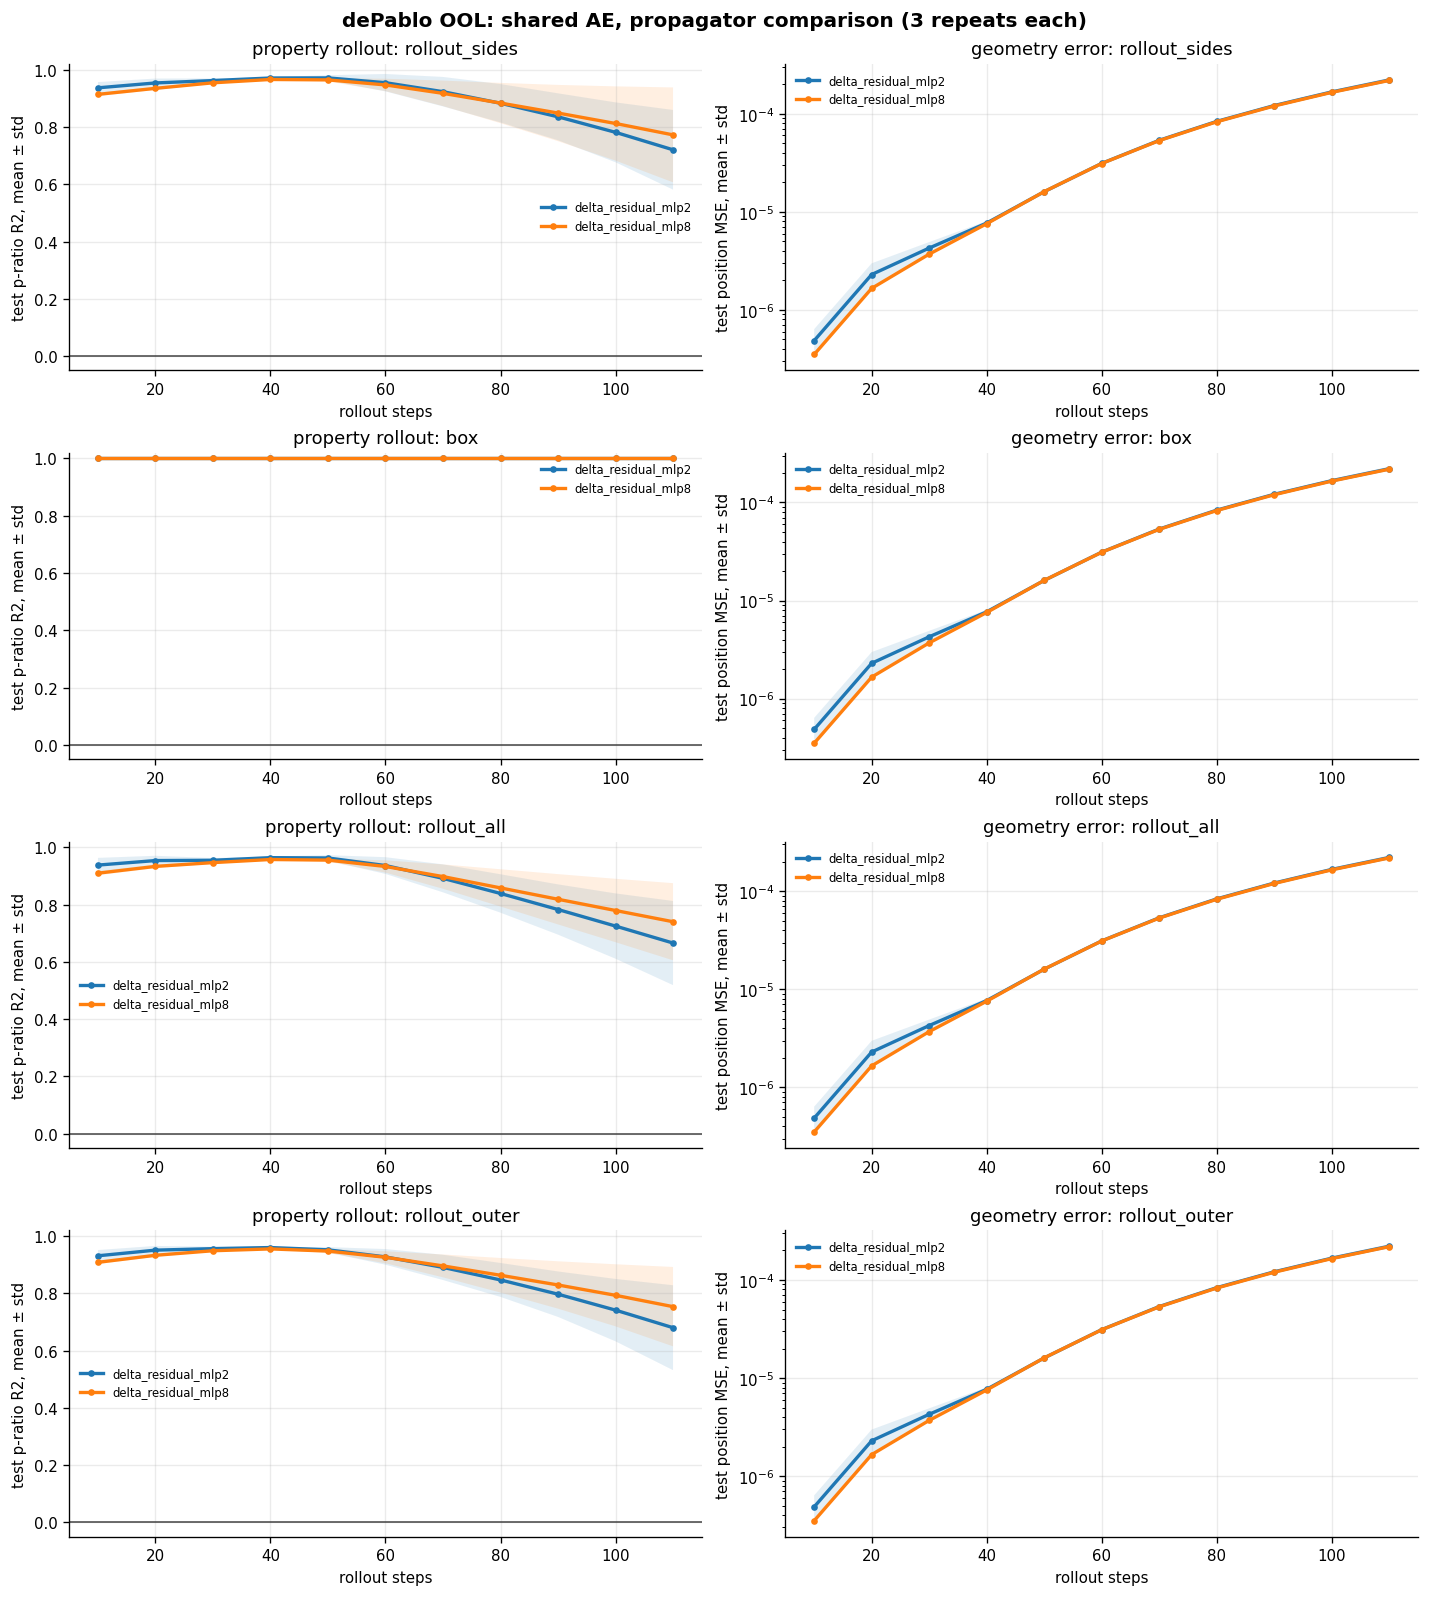

aggregate over repeats


,p_ratio_method,propagator,mean_p_ratio_r2,std_p_ratio_r2,min_p_ratio_r2_mean,step100_p_ratio_r2_mean,step100_p_ratio_r2_std,step200_p_ratio_r2_mean,step200_p_ratio_r2_std,mean_position_mse,std_position_mse,n_repeats
0,box,delta_residual_mlp2,1.000000,0.000000,1.000000,1.000000,0.000000,NaN,NaN,0.000064,0.000002,3
1,box,delta_residual_mlp8,1.000000,0.000000,1.000000,1.000000,0.000000,NaN,NaN,0.000064,0.000002,3
3,rollout_all,delta_residual_mlp8,0.884197,0.041041,0.739829,0.779052,0.110742,NaN,NaN,0.000064,0.000002,3
2,rollout_all,delta_residual_mlp2,0.873624,0.037393,0.665405,0.724670,0.114036,NaN,NaN,0.000064,0.000002,3
5,rollout_outer,delta_residual_mlp8,0.886348,0.040412,0.753192,0.792818,0.108388,NaN,NaN,0.000064,0.000002,3
4,rollout_outer,delta_residual_mlp2,0.875414,0.036210,0.679715,0.741054,0.108952,NaN,NaN,0.000064,0.000002,3
7,rollout_sides,delta_residual_mlp8,0.901392,0.047351,0.770582,0.812277,0.129602,NaN,NaN,0.000064,0.000002,3
6,rollout_sides,delta_residual_mlp2,0.899426,0.036425,0.720410,0.781396,0.104574,NaN,NaN,0.000064,0.000002,3


per-repeat summary


,p_ratio_method,propagator,repeat_idx,mean_p_ratio_r2,min_p_ratio_r2,step100_p_ratio_r2,step200_p_ratio_r2,mean_position_mse,step100_position_mse
0,box,delta_residual_mlp2,1,1.000000,1.000000,1.000000,NaN,0.000065,0.000169
1,box,delta_residual_mlp2,2,1.000000,1.000000,1.000000,NaN,0.000062,0.000159
2,box,delta_residual_mlp2,3,1.000000,1.000000,1.000000,NaN,0.000066,0.000173
3,box,delta_residual_mlp8,1,1.000000,1.000000,1.000000,NaN,0.000066,0.000171
4,box,delta_residual_mlp8,2,1.000000,1.000000,1.000000,NaN,0.000062,0.000161
5,box,delta_residual_mlp8,3,1.000000,1.000000,1.000000,NaN,0.000063,0.000164
6,rollout_all,delta_residual_mlp2,1,0.860682,0.556727,0.658858,NaN,0.000065,0.000169
7,rollout_all,delta_residual_mlp2,2,0.915768,0.832573,0.856348,NaN,0.000062,0.000159
8,rollout_all,delta_residual_mlp2,3,0.844420,0.606913,0.658805,NaN,0.000066,0.000173
9,rollout_all,delta_residual_mlp8,1,0.842389,0.603141,0.664743,NaN,0.000066,0.000171


In [27]:
# Plots: mean ± std over propagator repeats.
test_stats = rollout_stats_df[rollout_stats_df['split'].eq('test')].copy()
curve_df = (
    test_stats
    .groupby(['p_ratio_method', 'propagator', 'rollout_steps'], as_index=False)
    .agg(
        p_ratio_r2_mean=('p_ratio_r2', 'mean'),
        p_ratio_r2_std=('p_ratio_r2', 'std'),
        final_pos_mse_mean=('final_pos_mse', 'mean'),
        final_pos_mse_std=('final_pos_mse', 'std'),
        n_repeats=('repeat_idx', 'nunique'),
    )
)

methods = list(cfg['p_ratio_methods'])
fig, axes = plt.subplots(len(methods), 2, figsize=(11.8, 3.3 * len(methods)), constrained_layout=True, squeeze=False)
for row_idx, p_ratio_method in enumerate(methods):
    method_curve = curve_df[curve_df['p_ratio_method'].eq(p_ratio_method)].copy()
    for name, group in method_curve.groupby('propagator'):
        group = group.sort_values('rollout_steps')
        x = group['rollout_steps'].to_numpy(dtype=float)
        y = group['p_ratio_r2_mean'].to_numpy(dtype=float)
        yerr = group['p_ratio_r2_std'].fillna(0).to_numpy(dtype=float)
        axes[row_idx, 0].plot(x, y, marker='o', lw=2, ms=3, label=name)
        axes[row_idx, 0].fill_between(x, y - yerr, y + yerr, alpha=0.12)

        mse = group['final_pos_mse_mean'].to_numpy(dtype=float)
        mse_std = group['final_pos_mse_std'].fillna(0).to_numpy(dtype=float)
        lower = np.maximum(mse - mse_std, 1e-12)
        upper = mse + mse_std
        axes[row_idx, 1].plot(x, mse, marker='o', lw=2, ms=3, label=name)
        axes[row_idx, 1].fill_between(x, lower, upper, alpha=0.12)
    axes[row_idx, 0].axhline(0, color='0.25', lw=0.9)
    axes[row_idx, 0].set_ylim(-0.05, 1.02)
    axes[row_idx, 0].set_xlabel('rollout steps')
    axes[row_idx, 0].set_ylabel('test p-ratio R2, mean ± std')
    axes[row_idx, 0].set_title(f'property rollout: {p_ratio_method}')
    axes[row_idx, 1].set_yscale('log')
    axes[row_idx, 1].set_xlabel('rollout steps')
    axes[row_idx, 1].set_ylabel('test position MSE, mean ± std')
    axes[row_idx, 1].set_title(f'geometry error: {p_ratio_method}')
    for ax in axes[row_idx]:
        ax.legend(frameon=False, fontsize=7)
fig.suptitle(f"{source_spec['label']}: shared AE, propagator comparison ({cfg['propagator_repeats']} repeats each)", fontsize=12, fontweight='bold')
plt.show()

summary_by_repeat = (
    test_stats.groupby(['p_ratio_method', 'propagator', 'repeat_idx'], as_index=False)
    .agg(
        mean_p_ratio_r2=('p_ratio_r2', 'mean'),
        min_p_ratio_r2=('p_ratio_r2', 'min'),
        step100_p_ratio_r2=('p_ratio_r2', lambda s: float(test_stats.loc[s.index][test_stats.loc[s.index, 'rollout_steps'].eq(100)]['p_ratio_r2'].iloc[0]) if any(test_stats.loc[s.index, 'rollout_steps'].eq(100)) else np.nan),
        step200_p_ratio_r2=('p_ratio_r2', lambda s: float(test_stats.loc[s.index][test_stats.loc[s.index, 'rollout_steps'].eq(200)]['p_ratio_r2'].iloc[0]) if any(test_stats.loc[s.index, 'rollout_steps'].eq(200)) else np.nan),
        mean_position_mse=('final_pos_mse', 'mean'),
        step100_position_mse=('final_pos_mse', lambda s: float(test_stats.loc[s.index][test_stats.loc[s.index, 'rollout_steps'].eq(100)]['final_pos_mse'].iloc[0]) if any(test_stats.loc[s.index, 'rollout_steps'].eq(100)) else np.nan),
    )
)
summary = (
    summary_by_repeat.groupby(['p_ratio_method', 'propagator'], as_index=False)
    .agg(
        mean_p_ratio_r2=('mean_p_ratio_r2', 'mean'),
        std_p_ratio_r2=('mean_p_ratio_r2', 'std'),
        min_p_ratio_r2_mean=('min_p_ratio_r2', 'mean'),
        step100_p_ratio_r2_mean=('step100_p_ratio_r2', 'mean'),
        step100_p_ratio_r2_std=('step100_p_ratio_r2', 'std'),
        step200_p_ratio_r2_mean=('step200_p_ratio_r2', 'mean'),
        step200_p_ratio_r2_std=('step200_p_ratio_r2', 'std'),
        mean_position_mse=('mean_position_mse', 'mean'),
        std_position_mse=('mean_position_mse', 'std'),
        n_repeats=('repeat_idx', 'nunique'),
    )
    .sort_values(['p_ratio_method', 'mean_p_ratio_r2'], ascending=[True, False])
)
print('aggregate over repeats')
display(summary.round(6))
print('per-repeat summary')
display(summary_by_repeat.sort_values(['p_ratio_method', 'propagator', 'repeat_idx']).round(6))
